In [ ]:
from nltk.corpus import brown
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from huggingface_hub import notebook_login
from sklearn.metrics import accuracy_score, f1_score
plt.rcParams['text.parse_math'] = False

notebook_login()

In [30]:
# Test to see if POS tagged sentences can be accessed from nltk, otherwise use downloaded brown folder
print(brown.tagged_sents())

[[('The', 'AT'), ('Fulton', 'NP-TL'), ('County', 'NN-TL'), ('Grand', 'JJ-TL'), ('Jury', 'NN-TL'), ('said', 'VBD'), ('Friday', 'NR'), ('an', 'AT'), ('investigation', 'NN'), ('of', 'IN'), ("Atlanta's", 'NP$'), ('recent', 'JJ'), ('primary', 'NN'), ('election', 'NN'), ('produced', 'VBD'), ('``', '``'), ('no', 'AT'), ('evidence', 'NN'), ("''", "''"), ('that', 'CS'), ('any', 'DTI'), ('irregularities', 'NNS'), ('took', 'VBD'), ('place', 'NN'), ('.', '.')], [('The', 'AT'), ('jury', 'NN'), ('further', 'RBR'), ('said', 'VBD'), ('in', 'IN'), ('term-end', 'NN'), ('presentments', 'NNS'), ('that', 'CS'), ('the', 'AT'), ('City', 'NN-TL'), ('Executive', 'JJ-TL'), ('Committee', 'NN-TL'), (',', ','), ('which', 'WDT'), ('had', 'HVD'), ('over-all', 'JJ'), ('charge', 'NN'), ('of', 'IN'), ('the', 'AT'), ('election', 'NN'), (',', ','), ('``', '``'), ('deserves', 'VBZ'), ('the', 'AT'), ('praise', 'NN'), ('and', 'CC'), ('thanks', 'NNS'), ('of', 'IN'), ('the', 'AT'), ('City', 'NN-TL'), ('of', 'IN-TL'), ('Atlant

In [31]:
brown_df = pd.DataFrame(data = list(brown.tagged_words()), columns = ['word', 'tag'])
brown_df.head(10)

,word,tag
0,The,AT
1,Fulton,NP-TL
2,County,NN-TL
3,Grand,JJ-TL
4,Jury,NN-TL
5,said,VBD
6,Friday,NR
7,an,AT
8,investigation,NN
9,of,IN


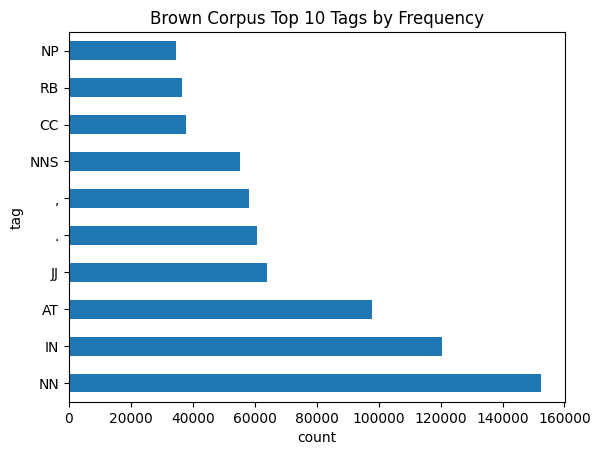

In [27]:
brown_df["tag"].value_counts().head(10).plot.barh()
plt.title("Brown Corpus Top 10 Tags by Frequency")
plt.xlabel("count")
plt.show()

In [37]:
# tagged_words() outputs a list of tuples, where each tuple is (word, part of speech / POS)

# Cased version to match brown corpus

model_name = "distilbert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Test tokenization with DistilBERT tokenizer

print(tokenizer("Computational Linguistics"))


{'input_ids': [101, 3291, 8223, 15012, 15937, 20815, 6592, 19251, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1]}


We will now start fine-tuning DistilBERT.

In [ ]:
# TODO: determine how to tokenize/encode dataset for training.
# tagged_sentences = list(brown.tagged_sents())

# for tagged_sentence in tagged_sentences:
#     words, tags = zip(*tagged_sentence)

#     encoding = tokenizer(
#         words,
#         is_split_into_words=True,
#     )

In [ ]:
# TODO: Model for sequence classification (base DistilBERT)

# num_labels = 50 # just an arb. number for now

# model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels = num_labels)

ModuleNotFoundError: Could not import module 'DistilBertForSequenceClassification'. Are this object's requirements defined correctly?

In [40]:
#Metrics during training, f1 score and accuracy score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(y_true = labels, y_pred = preds, average = "weighted")
    acc = accuracy_score(y_true = labels, y_pred = preds)
    return {"accuracy": acc, "f1": f1}

In [ ]:
# Training Arguments and Trainer -> We can fine-tune the base DistilBERT with the encoded version of our dataset

batch_size = 64
output_model_name = f"{model_name}-pos"

training_args = TrainingArguments(
    output_dir = output_model_name,
    num_train_epochs = 3,
    learning_rate = 2e-5,
    per_device_train_batch_size = batch_size,
    per_device_eval_batch_size = batch_size,
    eval_strategy="epoch",
    push_to_hub=True,
    log_level="error"
)

#trainer = Trainer(model = stuff, stuff, etc)
#trainer.train()s